# Supplementary Fig. 6 — chromosomal-rearrangement breakpoint coverage

For each recurrent AML translocation / inversion partner gene, this figure shows the exon–intron
structure of the gene (lower track) and the sub-regions of that gene targeted by the **custom
TETRIS-seq CNV panel** (upper track, shaded), demonstrating that the panel tiles the breakpoint
regions of the common chromosomal rearrangements. One panel is produced per gene, grouped by fusion
pair (ABL1/BCR, PML/RARA, CBFB/MYH11, RUNX1/RUNX1T1, DEK/NUP214, MLLT3/KMT2A).

## Data availability

**Exon coordinates are fetched programmatically** from Ensembl (GRCh37/hg19, via the REST API),
using one transcript per gene (`GENE_TRANSCRIPTS`). Results are cached under
`Data_files/ensembl_exon_cache/`, so the lookups run once per gene and the notebook then runs offline.

The only other input is the panel design:

| file | contents | location |
|---|---|---|
| `TWIST_CNV_panel_TE-95031423_h19.bed` | genomic intervals targeted by the custom TWIST CNV panel (hg19) | Data_files |

| `ensembl_exon_cache/` | cached Ensembl exon lookups (created on first run) | Data_files |

## 1. Imports and colours

In [1]:
import csv
import json
import os
import urllib.request
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec
from matplotlib.lines import Line2D

In [2]:
orange1 = '#feedde'
orange2 = '#fdbe85'
orange3 = '#fd8d3c'
orange4 = '#e6550d'
orange5 = '#a63603'
blue1 = '#eff3ff'
blue2 = '#bdd7e7'
blue3 = '#6baed6'
blue4 = '#3182bd'
blue5 = '#08519c'
green1 = '#edf8e9'
green2 = '#bae4b3'
green3 = '#74c476'
green4 = '#31a354'
green5 = '#006d2c'
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'
purple1 = '#f2f0f7'
purple2 = '#cbc9e2'
purple3 = '#9e9ac8'
purple4 = '#756bb1'
purple5 = '#54278f'
red1 = '#fee5d9'
red2 = '#fcae91'
red3 = '#fb6a4a'
red4 = '#de2d26'
red5 = '#a50f15'

In [3]:
# --- exon structures fetched from Ensembl (GRCh37/hg19), cached on disk ---------------
# One transcript per gene (the transcript whose exon boundaries this figure uses); fetching them
# programmatically means the exon/intron coordinates are not transcribed by hand.
GENE_TRANSCRIPTS = {   # Ensembl GRCh37 transcripts
    'DEK':     'ENST00000397239',
    'NUP214':  'ENST00000359428',
    'RUNX1':   'ENST00000300305',
    'RUNX1T1': 'ENST00000265814',
    'KMT2A':   'ENST00000534358',
    'MLLT3':   'ENST00000380338',
    'BCR':     'ENST00000305877',
    'ABL1':    'ENST00000318560',
    'PML':     'ENST00000268058',
    'RARA':    'ENST00000394089',
    'CBFB':    'ENST00000412916',
    'MYH11':   'ENST00000396324',
}

_EXON_CACHE_DIR = 'Data_files/ensembl_exon_cache'
os.makedirs(_EXON_CACHE_DIR, exist_ok=True)

def _fetch_transcript_exons(transcript):
    """Exons of an Ensembl transcript in hg19 genomic coordinates, ordered 5' -> 3'."""
    url = ('https://grch37.rest.ensembl.org/lookup/id/' + transcript
           + '?expand=1;content-type=application/json')
    request = urllib.request.Request(url, headers={'Content-type': 'application/json'})
    with urllib.request.urlopen(request, timeout=60) as response:
        record = json.load(response)
    exons = [(min(exon['start'], exon['end']), max(exon['start'], exon['end'])) for exon in record['Exon']]
    exons.sort(reverse=(record['strand'] == -1))   # exon 1 first, whichever strand the gene is on
    return record['strand'], exons

def gene_structure(gene):
    """{'Exon 1': ('exon', start, stop), 'Intron 1-2': ('intron', start, stop), ...} in hg19."""
    transcript = GENE_TRANSCRIPTS[gene]
    cache_path = os.path.join(_EXON_CACHE_DIR, gene + '_' + transcript + '_grch37_genomic.json')
    if os.path.exists(cache_path):
        strand, exons = json.load(open(cache_path))
        exons = [tuple(exon) for exon in exons]
    else:
        strand, exons = _fetch_transcript_exons(transcript)
        json.dump([strand, exons], open(cache_path, 'w'))

    coordinates = {}
    for exon_number, exon in enumerate(exons, 1):
        coordinates['Exon ' + str(exon_number)] = ('exon', exon[0], exon[1])
        if exon_number < len(exons):
            next_exon = exons[exon_number]
            intron_start = min(exon[1], next_exon[1]) + 1
            intron_stop = max(exon[0], next_exon[0]) - 1
            coordinates['Intron ' + str(exon_number) + '-' + str(exon_number + 1)] = ('intron', intron_start, intron_stop)

    return coordinates

## 2. Helper functions

In [4]:
def panel_coverage_dict(panel_bed):
    #panel coverage
    with open(panel_bed, 'r') as textfile:
        read_reader = csv.reader(textfile, delimiter = '\t')  #csv.reader returns a reader object which will iterate over lines in the csvfile
        row_count = 0
        panel_coverage = {}
        for row in read_reader:
            if row_count > 2:
                chromosome = row[0]
                start = int(row[1]) #start position of that part of the chromosome
                end = int(row[2]) #end position of that part of the chromosome

                if chromosome in panel_coverage.keys():
                    panel_coverage[chromosome].append((start, end))
                else:
                    panel_coverage[chromosome]=([(start, end)])

            row_count+=1

    return panel_coverage

In [5]:
def region_ideogram(region_coordinates, color):
    if color == 'blue':
        color_lookup = {'exon': grey3, 'intron': 'white'}
    if color == 'yellow':
        color_lookup = {'exon': grey3, 'intron': 'white'}
    
    xranges = []
    colors = []
    mid_points = []
    labels = []

    for k, v in region_coordinates.items():
        start = int(v[1])
        stop = int(v[2])
        label = k.split()[1]
        intron_or_exon = v[0]
        width = stop - start
        mid_point = start + (width/2)
        xranges.append((start, width))
        colors.append(color_lookup[intron_or_exon])
        if intron_or_exon == 'exon':

            mid_points.append(mid_point)
            labels.append(label)

    return xranges, [0, 1.0], colors, mid_points, labels

In [6]:
def plot_gene(region_coordinates, ax, region, color):

    xranges, yrange, colors, midpoints, labels = region_ideogram(region_coordinates, color)

    ax.broken_barh(xranges, yrange, facecolors= colors, edgecolor = 'black', alpha = 1.0)

    ax.set_xticks(midpoints)
    ax.set_xticklabels(labels, rotation = 0, fontsize = 12)
    ax.set_yticks([])
    ax.text(-0.013, 0.35, region, transform=ax.transAxes, fontsize = 20, ha = 'right')
    ax.text(-0.013, -0.5, 'exons:', transform=ax.transAxes, fontsize = 16, ha = 'right')
    ax.xaxis.set_tick_params(width=0.8, color = grey3, length = 6, labelsize = 16)

    ax.minorticks_off()

    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    return ax

In [7]:
def plot_regions_targeted_by_panel(chromosome, panel_coverage, ax, y_max, region_start, region_stop):
    #only the panel intervals within the plotted region are drawn, and they are trimmed to its edges,
    #so the saved figure contains no shapes outside the axes (the rest of the chromosome is targeted too)

    regions_covered = panel_coverage[chromosome]

    for positions in regions_covered:
        if (positions[1] < region_start) or (positions[0] > region_stop):
            continue
        start_position = max(positions[0], region_start)
        stop_position = min(positions[1], region_stop)

        bottom = 0
        top = y_max

        x = [start_position, start_position, stop_position, stop_position]
        y = [bottom, top, top, bottom]
#         ax.fill(x, y, color= '#deebf7', fill = True, alpha = 1.0, linewidth = 1, zorder = 0) #fill in the box with stars
        ax.fill(x, y, color= purple2, fill = True, alpha = 0.6, linewidth = 1, zorder = 0) #fill in the box with stars

    return ax

In [ ]:
def read_depths_plot(region_name, region_chromosome, region_start, region_stop, region_coordinates, panel_coverage, strand, color):
    plt.close('all')
    f = plt.figure(figsize=(20, 1.5))
    gs = matplotlib.gridspec.GridSpec(2, 1, width_ratios=[1], height_ratios=[1,1])
    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1])
    gs.update(hspace=0.05)

    m_size = 100
    axisfont=15
    titlefont=15
    axislabelfont=15
    exonfont=12

    ax1.plot([region_start, region_stop], [0, 0], color = grey3, lw = 2, linestyle = ':')

    #gene IDEOGRAM
    plot_gene(region_coordinates, ax2, region_name, color)

    #REGIONS COVERED BY PANEL:
    plot_regions_targeted_by_panel(region_chromosome, panel_coverage, ax1, 1, region_start-500, region_stop+500)

    # CONFIGURING THE GRAPH APPEARANCE
    #Set the x and y axis limits
    if strand == '+':
        ax1.set_xlim(region_start-500, region_stop+500)
        ax2.set_xlim(region_start-500, region_stop+500)
    if strand == '-':
        ax1.set_xlim(region_stop+500, region_start-500)
        ax2.set_xlim(region_stop+500, region_start-500)
    ax1.set_ylim(0, 1)

    #x-axis ticks
    x1_major_ticks = []
    x1_major_tick_labels = []
    ax1.set_xticks(x1_major_ticks)
    ax1.set_xticklabels(x1_major_tick_labels, fontsize = axisfont)
    ax1.set_yticks(x1_major_ticks)
    ax1.set_yticklabels(x1_major_tick_labels, fontsize = axisfont)

#     ax1.tick_params(axis='y', which='major', labelsize=13)

    #Only show the required axis lines
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    ax1.spines['left'].set_visible(False)

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.spines['left'].set_visible(False)

    for axis in ['left']:
        ax1.spines[axis].set_linewidth(1.5)
        ax1.spines[axis].set_color('#969696')
    ax1.yaxis.set_tick_params(width=1, color = '#969696', length = 6)

    legend_elements = [Line2D([0], [0], marker = 's', color='#deebf7', alpha=1.0, markersize = 12, \
                      lw=0, label='regions covered by custom panel')]
    
    plt.tight_layout()
    return plt.show()

## 3. Load the custom-panel coverage

In [23]:
panel_bed = 'Data_files/TWIST_CNV_panel_TE-95031423_h19.bed'
panel_coverage = panel_coverage_dict(panel_bed)

## 4. Per-region coverage plots

### DEK

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_64728/2575220309.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


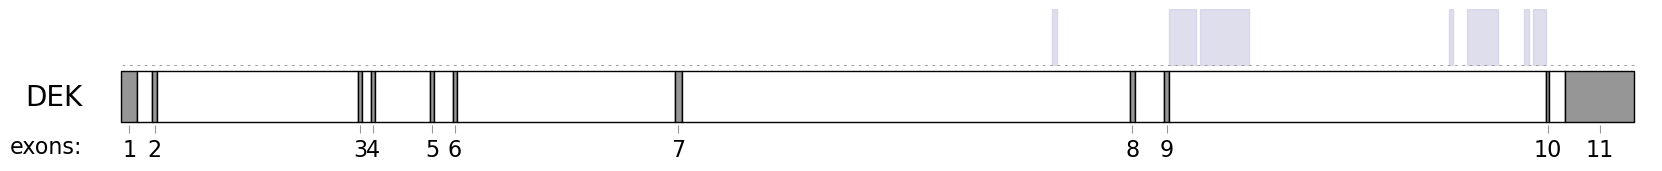

In [24]:
#DEK
DEK_chromosome = 'chr6'
DEK_start = 18224099
DEK_stop = 18265054
DEK_coordinates = gene_structure('DEK')

color = 'blue'

read_depths_plot('DEK', DEK_chromosome, DEK_start, DEK_stop, DEK_coordinates, panel_coverage, '-', color)

### NUP214

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_64728/2575220309.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


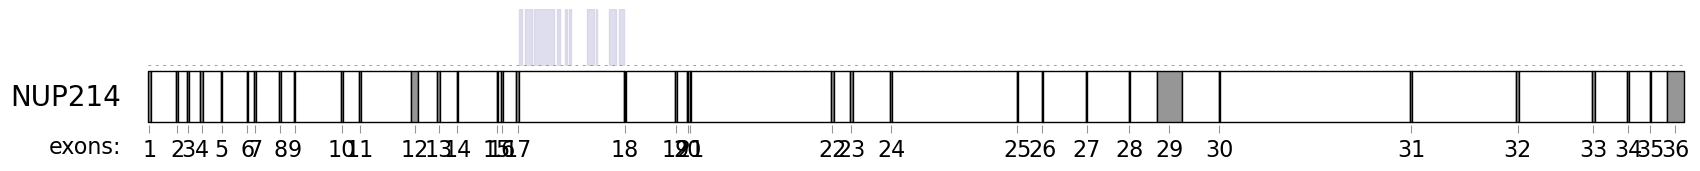

In [25]:
#NUP214
NUP214_chromosome = 'chr9'
NUP214_start = 134000948
NUP214_stop = 134110057
NUP214_coordinates = gene_structure('NUP214')

color = 'yellow'

read_depths_plot('NUP214', NUP214_chromosome, NUP214_start, NUP214_stop, NUP214_coordinates, panel_coverage, '+', color)

### RUNX1

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_64728/2575220309.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


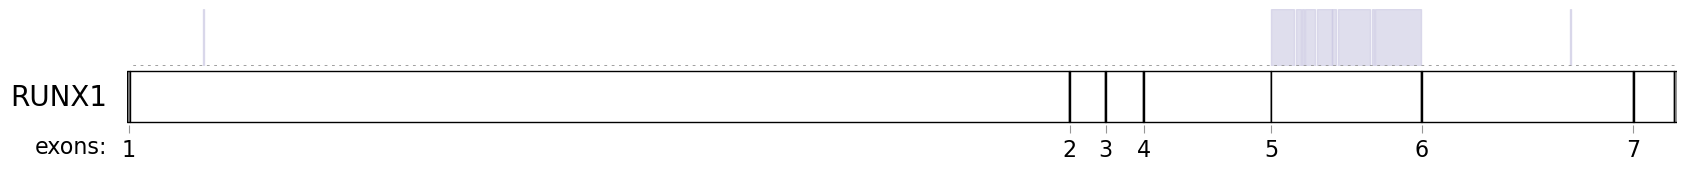

In [26]:
#RUNX1
RUNX1_chromosome = 'chr21'
RUNX1_start = 36164907
RUNX1_stop = 36421139
RUNX1_coordinates = gene_structure('RUNX1')

color = 'yellow'

read_depths_plot('RUNX1', RUNX1_chromosome, RUNX1_start, RUNX1_stop, RUNX1_coordinates, panel_coverage, '-', color)

### RUNX1T1

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_64728/2575220309.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


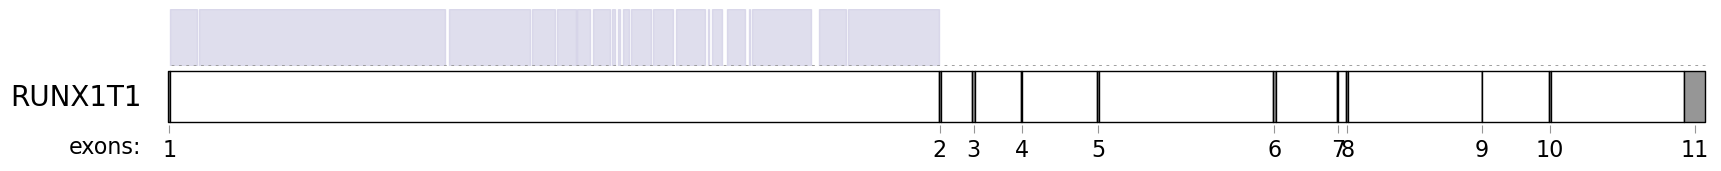

In [27]:
#RUNX1T1
RUNX1T1_chromosome = 'chr8'
RUNX1T1_start = 92971152
RUNX1T1_stop = 93088364
RUNX1T1_coordinates = gene_structure('RUNX1T1')

color = 'blue'

read_depths_plot('RUNX1T1', RUNX1T1_chromosome, RUNX1T1_start, RUNX1T1_stop, RUNX1T1_coordinates, panel_coverage, '-', color)

### KMT2A

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_64728/2575220309.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


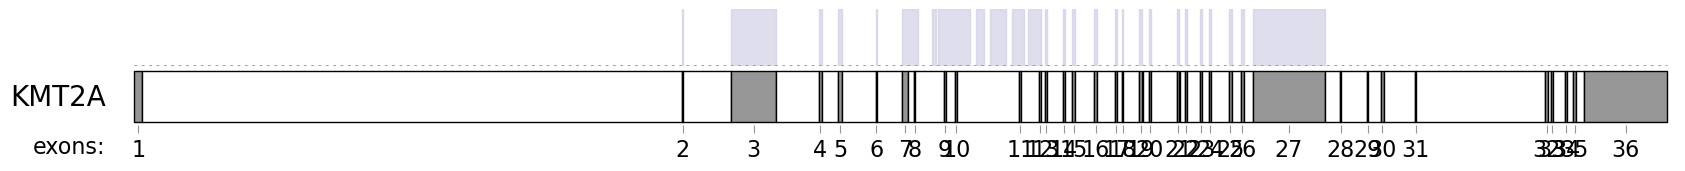

In [28]:
#KMT2A
KMT2A_chromosome = 'chr11'
KMT2A_start = 118307205
KMT2A_stop = 118397539
KMT2A_coordinates = gene_structure('KMT2A')

color = 'yellow'

read_depths_plot('KMT2A', KMT2A_chromosome, KMT2A_start, KMT2A_stop, KMT2A_coordinates, panel_coverage, '+', color)

### MLLT3

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_64728/2575220309.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


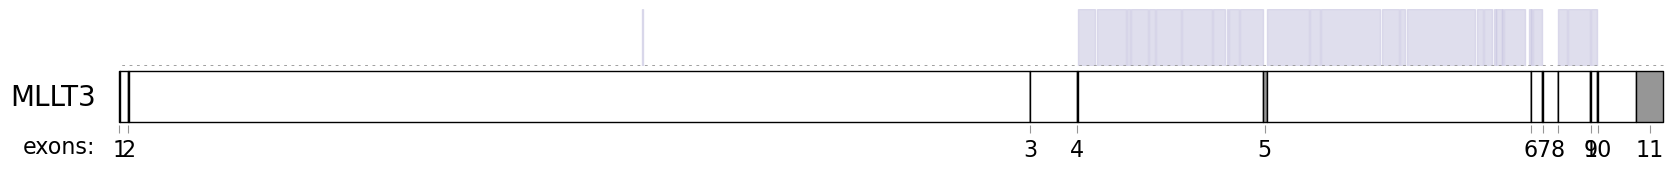

In [29]:
#MLLT3
MLLT3_chromosome = 'chr9'
MLLT3_start = 20341663
MLLT3_stop = 20622542
MLLT3_coordinates = gene_structure('MLLT3')

color = 'blue'

read_depths_plot('MLLT3', MLLT3_chromosome, MLLT3_start, MLLT3_stop, MLLT3_coordinates, panel_coverage, '-', color)

### BCR

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_64728/2575220309.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


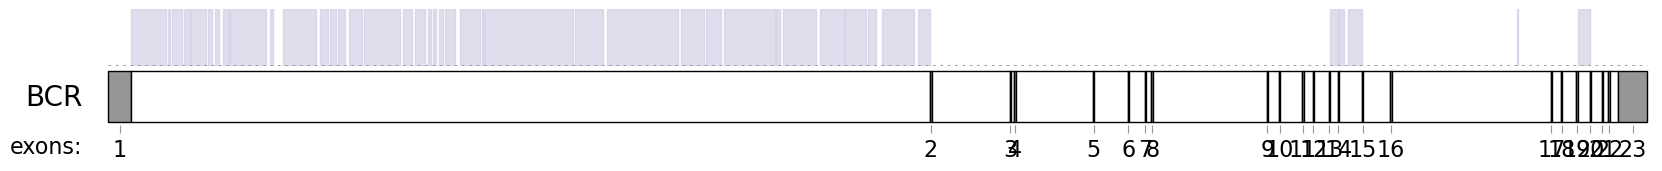

In [30]:
#BCR
BCR_chromosome = 'chr22'
BCR_start = 23522397
BCR_stop = 23660224
BCR_coordinates = gene_structure('BCR')

color = 'blue'

read_depths_plot('BCR', BCR_chromosome, BCR_start, BCR_stop, BCR_coordinates, panel_coverage, '+', color)

### ABL1

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_64728/2575220309.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


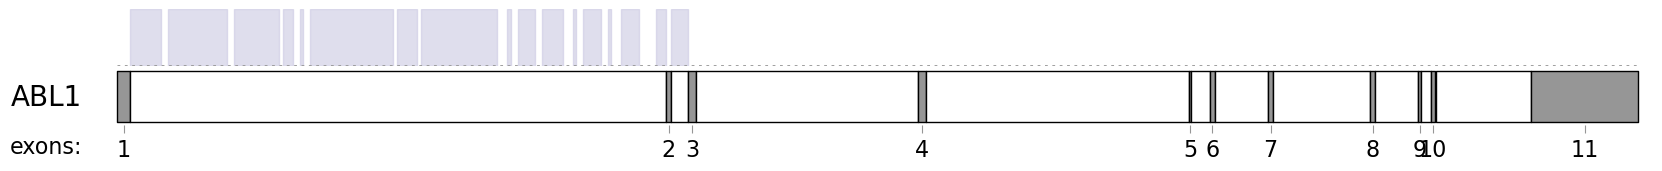

In [31]:
#ABL1
ABL1_chromosome = 'chr9'
ABL1_start = 133710453
ABL1_stop = 133763062
ABL1_coordinates = gene_structure('ABL1')

color = 'yellow'

read_depths_plot('ABL1', ABL1_chromosome, ABL1_start, ABL1_stop, ABL1_coordinates, panel_coverage, '+', color)

### PML

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_64728/2575220309.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


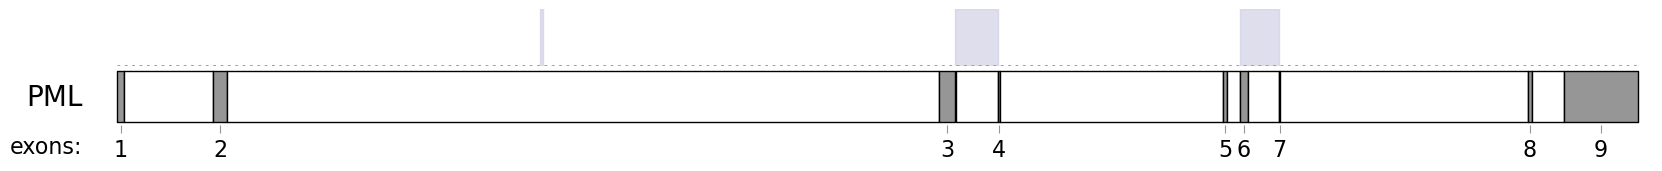

In [32]:
#PML
PML_chromosome = 'chr15'
PML_start = 74287058
PML_stop = 74339112
PML_coordinates = gene_structure('PML')

color = 'blue'

read_depths_plot('PML', PML_chromosome, PML_start, PML_stop, PML_coordinates, panel_coverage, '+', color)

### RARA

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_64728/2575220309.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


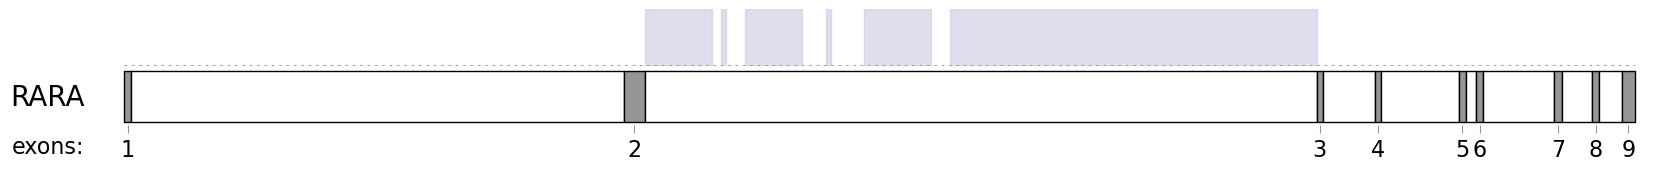

In [33]:
#RARA
RARA_chromosome = 'chr17'
RARA_start = 38474533
RARA_stop = 38512583
RARA_coordinates = gene_structure('RARA')

color = 'yellow'

read_depths_plot('RARA', RARA_chromosome, RARA_start, RARA_stop, RARA_coordinates, panel_coverage, '+', color)

### CBFB

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_64728/2575220309.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


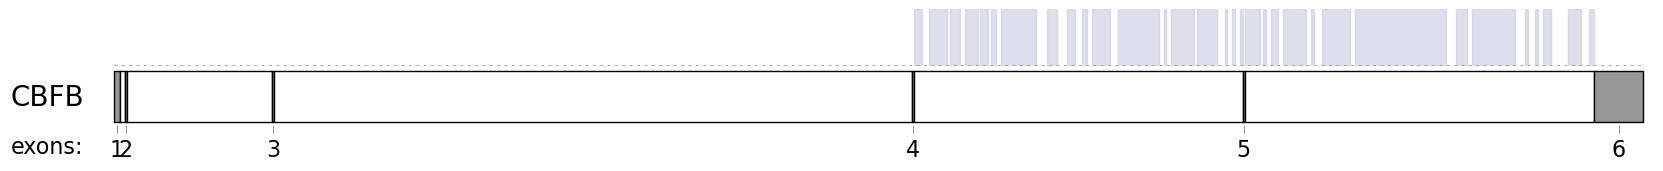

In [34]:
#CBFB
CBFB_chromosome = 'chr16'
CBFB_start = 67063148
CBFB_stop = 67134925

CBFB_coordinates = gene_structure('CBFB')

color = 'yellow'

read_depths_plot('CBFB', CBFB_chromosome, CBFB_start, CBFB_stop, CBFB_coordinates, panel_coverage, '+', color)

### MYH11

/var/folders/nm/cxwh2kyn0zl_791cy3yp3fjw0000gp/T/ipykernel_64728/2575220309.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


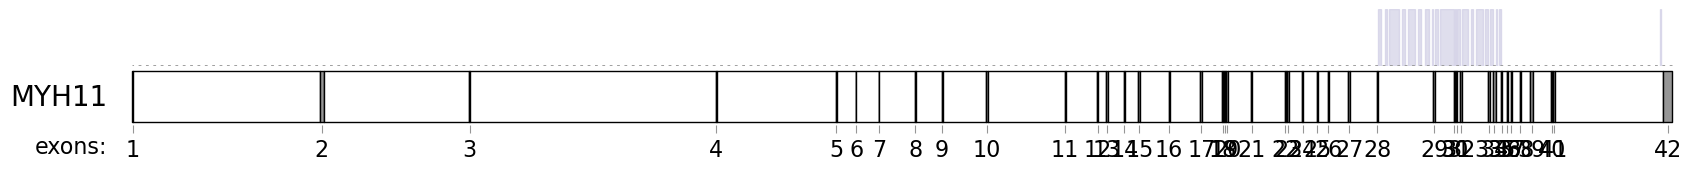

In [35]:
#MYH11
MYH11_chromosome = 'chr16'
MYH11_start = 15797029
MYH11_stop = 15950868
MYH11_coordinates = gene_structure('MYH11')

color = 'blue'

read_depths_plot('MYH11', MYH11_chromosome, MYH11_start, MYH11_stop, MYH11_coordinates, panel_coverage, '-', color)